# Exemplo 1 - Probabilidade de precipitação anual

1. Calcule as precipitações anuais na bacia do rio Purus de 1980 a 2010 (filtrar apenas anos completos).
2. Faça um gráfico da série temporal da precipitações anuais.
3. Qual é a probabilidade de que a precipitação anual R em qualquer ano seja inferior a 1900 mm? Maior que 2000 mm? Entre 1900 e 2000 mm?

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy

In [2]:
# Baixa dados da base CABra
!gdown 16Ey3eavHOkWiU7g5xpG1g8Mq87vuFsh4

Downloading...
From: https://drive.google.com/uc?id=16Ey3eavHOkWiU7g5xpG1g8Mq87vuFsh4
To: /content/CABra_1_climate+streamflow_edit.csv
100% 904k/904k [00:00<00:00, 59.5MB/s]


In [3]:
df_cabra  = pd.read_csv('CABra_1_climate+streamflow_edit.csv', index_col= 0, sep =',')
df_cabra.index=pd.to_datetime(df_cabra.index)
df_cabra

,p_ens(mm),tmin_ens(oC),tmax_ens(oC),rh_ens(%),wnd_ens(m/s),srad_ens(MJm-2),et_ens(mm),pet_pm(mm),pet_pt(mm),pet_hg(mm),Streamflow(m3/s)
data,,,,,,,,,,,
1980-10-01,4.669,22.521,31.019,85.222,0.694,17.078,3.777,4.381,5.276,4.199,1165.800
1980-10-02,11.884,22.645,31.321,82.020,0.760,15.329,4.022,4.040,4.781,3.780,1181.200
1980-10-03,9.195,22.308,30.400,86.096,0.615,15.450,4.173,3.985,4.791,3.761,1194.400
1980-10-04,9.348,21.887,30.540,85.902,0.691,15.414,3.898,4.003,4.778,3.745,1201.000
1980-10-05,14.407,19.680,26.941,88.454,1.502,11.080,2.477,3.103,3.475,2.521,1203.200
...,...,...,...,...,...,...,...,...,...,...,...
2010-09-26,1.146,23.299,34.851,71.702,1.472,21.459,3.495,5.956,6.675,5.541,938.606
2010-09-27,0.545,22.975,35.614,68.785,1.633,23.953,3.689,6.683,7.431,6.214,933.871
2010-09-28,0.289,24.676,36.276,63.917,1.830,23.573,3.364,6.664,7.406,6.268,931.509


In [4]:
# Selecionar apenas os anos inteiros
df_pluv = df_cabra[['p_ens(mm)']]['1981':'2009'].copy()
df_pluv

,p_ens(mm)
data,
1981-01-01,6.233
1981-01-02,22.345
1981-01-03,8.493
1981-01-04,7.291
1981-01-05,9.607
...,...
2009-12-27,5.233
2009-12-28,10.419
2009-12-29,5.966


## 1. Cálculo da precipitação anual

In [5]:
# Acumula dados anuais
df_prec_anual  = df_pluv.resample("YE").sum()
df_prec_anual

,p_ens(mm)
data,
1981-12-31,2109.139
1982-12-31,2140.691
1983-12-31,1845.893
1984-12-31,2225.567
1985-12-31,2342.434
1986-12-31,2235.779
1987-12-31,2025.088
1988-12-31,1999.841
1989-12-31,2150.553


## 2. Gráfico da série temporal da precipitação anual

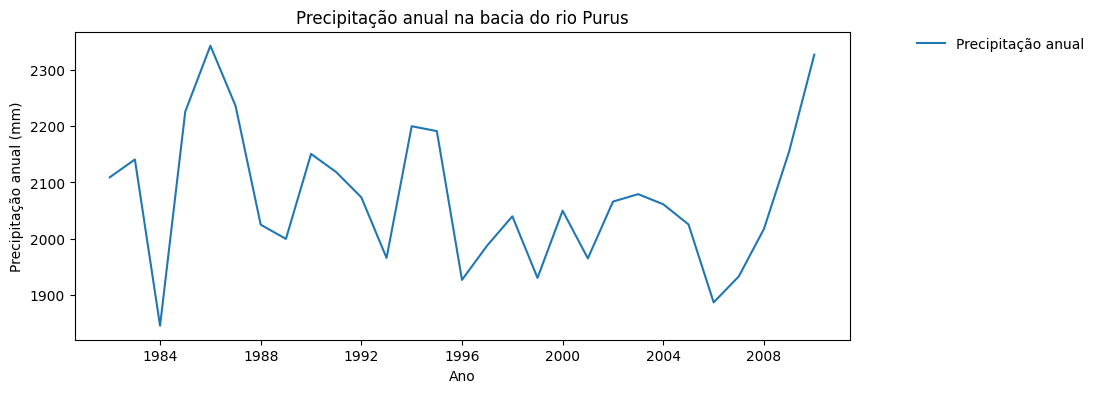

In [6]:
# Plot
plt.figure(figsize=(10,4))
plt.plot(df_prec_anual['p_ens(mm)'], label='Precipitação anual')
plt.xlabel('Ano')
plt.ylabel('Precipitação anual (mm)')
plt.title('Precipitação anual na bacia do rio Purus')
plt.legend(bbox_to_anchor=(1.08, 1), loc='upper left', borderaxespad=0.,frameon=False)
plt.savefig('precipitação_anual_Purus.png', dpi = 300, bbox_inches='tight')
plt.show()

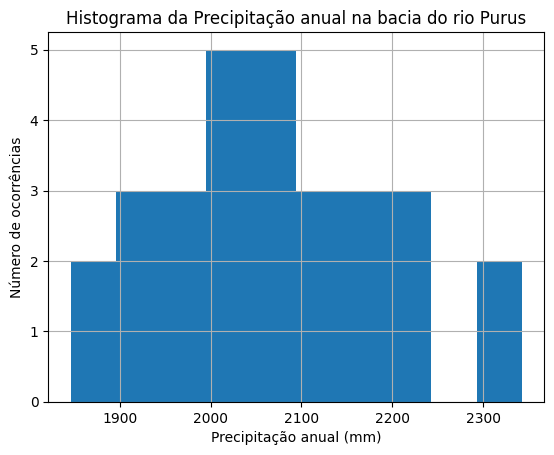

In [7]:
plt.xlabel('Precipitação anual (mm)')
plt.ylabel('Número de ocorrências')
plt.title('Histograma da Precipitação anual na bacia do rio Purus')
df_prec_anual['p_ens(mm)'].hist()
plt.savefig('histograma_precipitação_anual_Purus.png', dpi = 300, bbox_inches='tight')
plt.show();

## 3. Qual é a probabilidade de que a precipitação anual R em qualquer ano seja:
* Inferior a 1900 mm?
* Maior que 2000 mm?
* Entre 1900 e 2000 mm?

**Definição de probabilidade**

Se uma amostra de $n$ observações tiver $n_a$ valores no intervalo do evento A, então a frequência relativa de A é $n_A/n$. À medida que o tamanho da amostra aumenta, a frequência relativa torna-se uma estimativa progressivamente melhor da probabilidade do evento, ou seja,
$$
P(A)=\lim _{n \rightarrow \infty} \frac{n_A}{n}
$$

Vamos aproximar a probabilidade de A pela sua frequências relativa:
$$
P(A) \approx \frac{n_A}{n}
$$


In [8]:
# O tamanho da minha amostra n é:
n = len(df_prec_anual['p_ens(mm)'])
print('Temos', n, 'anos de dados')

Temos 29 anos de dados


### Eventos

* $A$ é o evento $R < 1900$ mm
* $B$ é o evento $R > 2000$ mm
* $C$ é o evento $1900 < R < 2000$ mm

In [9]:
# Evento A
df_prec_anual['p_ens(mm)'][df_prec_anual['p_ens(mm)'] < 1900]

,p_ens(mm)
data,
1983-12-31,1845.893
2005-12-31,1887.261


In [10]:
n_A = len(df_prec_anual['p_ens(mm)'][df_prec_anual['p_ens(mm)'] < 1900])
n_A

2

In [11]:
# Evento B
df_prec_anual['p_ens(mm)'][df_prec_anual['p_ens(mm)'] > 2000]

,p_ens(mm)
data,
1981-12-31,2109.139
1982-12-31,2140.691
1984-12-31,2225.567
1985-12-31,2342.434
1986-12-31,2235.779
1987-12-31,2025.088
1989-12-31,2150.553
1990-12-31,2118.373
1991-12-31,2073.555


In [12]:
n_B = len(df_prec_anual['p_ens(mm)'][df_prec_anual['p_ens(mm)'] > 2000])
n_B

20

## Podemos aproximar a probabilidade de A e de B por


In [13]:
P_A = n_A/n
P_B = n_B/n
print('A probabilidade de R < 1900 mm é', P_A)
print('A probabilidade de R > 2000 mm é', P_B)

A probabilidade de R < 1900 mm é 0.06896551724137931
A probabilidade de R > 2000 mm é 0.6896551724137931


## A probabilidade de C é


In [14]:
parcial = df_prec_anual['p_ens(mm)'][df_prec_anual['p_ens(mm)'] > 1900]
parcial

,p_ens(mm)
data,
1981-12-31,2109.139
1982-12-31,2140.691
1984-12-31,2225.567
1985-12-31,2342.434
1986-12-31,2235.779
1987-12-31,2025.088
1988-12-31,1999.841
1989-12-31,2150.553
1990-12-31,2118.373


In [15]:
final = parcial[parcial < 2000]
final

,p_ens(mm)
data,
1988-12-31,1999.841
1992-12-31,1966.095
1995-12-31,1927.178
1996-12-31,1988.107
1998-12-31,1930.673
2000-12-31,1965.260
2006-12-31,1933.371


In [16]:
n_C = len(final)
n_C

7

In [17]:
P_C = n_C/n
P_C

0.2413793103448276

In [18]:
P_A + P_B + P_C

1.0

In [19]:
P_C = 1 - (P_A + P_B)
print('A probabilidade de 1900 < R < 2000 mm é', P_C)

A probabilidade de 1900 < R < 2000 mm é 0.2413793103448275


# Exemplo 2 - Probabilidade consecutiva de precipitação anual

Supondo que a precipitação anual na bacia Purus seja um processo independente.
* Calcule a probabilidade de que haverá dois anos sucessivos de precipitação inferior a 2000 mm.
* Compare esta probabilidade estimada com a frequência relativa deste evento no conjunto de dados de 1981 a 2009.

### Evento

* Suponha que $D$ é o evento $R < 2000$ mm para um ano qualquer
* Suponha que $E$ é o evento $R < 2000$ mm para dois anos consecutivos

In [20]:
n_D = len(df_prec_anual['p_ens(mm)'][df_prec_anual['p_ens(mm)'] < 2000])
P_D = n_D/n
print('A probabilidade de R < 2000 mm é', P_D)

P_E = P_D**2
print('A probabilidade de R < 2000 mm em dois anos consecutivos é', P_E)

A probabilidade de R < 2000 mm é 0.3103448275862069
A probabilidade de R < 2000 mm em dois anos consecutivos é 0.09631391200951249


In [21]:
df_prec_anual['2000'] = 2000
#df_prec_anual

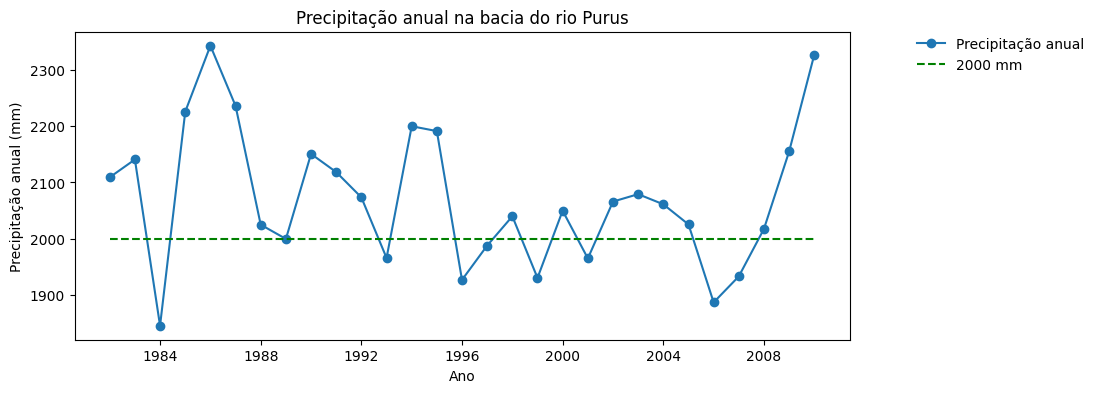

In [22]:
# Plot
plt.figure(figsize=(10,4))
plt.plot(df_prec_anual['p_ens(mm)'], '-o', label='Precipitação anual')
plt.xlabel('Ano')
plt.ylabel('Precipitação anual (mm)')
plt.title('Precipitação anual na bacia do rio Purus')
plt.plot(df_prec_anual['2000'], color="green", label="2000 mm", ls = "--")
plt.legend(bbox_to_anchor=(1.08, 1), loc='upper left', borderaxespad=0.,frameon=False)
plt.savefig('precipitação_anual_Purus.png', dpi = 300, bbox_inches='tight')
plt.show()

In [34]:
n, n-1

(29, 28)

Para n = 29 anos de observação temos n-1 = 28 possibilidades de anos subsequentes (pares de anos sequenciais)

In [44]:
# Examinando o gráfico observa-se que a frequência relativa deste evento no conjunto de dados de 1981 a 2009 é
n_evento = 2 # existem dois pares de precipitação sequenciais abaixo da linha tracejada verde

P_evento = n_evento/(n-1)
print('A probabilidade de R < 2000 mm em dois anos consecutivos é', P_evento)

A probabilidade de R < 2000 mm em dois anos consecutivos é 0.07142857142857142


In [45]:
P_E, P_evento

(0.09631391200951249, 0.07142857142857142)

In [46]:
# print 2 decimal places
print('A probabilidade de R < 1900 mm é {:.2f}'.format(P_A))
print('A probabilidade de R > 2000 mm é {:.2f}'.format(P_B))
print('A probabilidade de 1900 < R < 2000 mm é {:.2f}'.format(P_C))
print('A probabilidade de R < 2000 mm é {:.2f}'.format(P_D))
print('A probabilidade de R < 2000 mm em dois anos consecutivos é {:.2f}'.format(P_E))
print('A probabilidade de R < 2000 mm em dois anos consecutivos é {:.2f}'.format(P_evento))

A probabilidade de R < 1900 mm é 0.07
A probabilidade de R > 2000 mm é 0.69
A probabilidade de 1900 < R < 2000 mm é 0.24
A probabilidade de R < 2000 mm é 0.31
A probabilidade de R < 2000 mm em dois anos consecutivos é 0.10
A probabilidade de R < 2000 mm em dois anos consecutivos é 0.07


As probabilidades estimadas a partir de dados amostrais, como nos Exemplos 1 e 2, são aproximadas, porque dependem dos valores específicos das observações numa amostra de tamanho limitado. Uma abordagem alternativa é ajustar uma função de distribuição de probabilidade aos dados e depois determinar as probabilidades de eventos a partir desta função de distribuição.